In [1]:
import time
import pandas as pd
from tqdm import tqdm
import mplfinance as mpf
from binance import Client

In [2]:
client = Client()

In [3]:
exchange_info = client.get_exchange_info()

In [4]:
symbols = [symbol["symbol"] for symbol in exchange_info["symbols"]]
symbols = [symbol for symbol in symbols if symbol.endswith("USDT")]
symbols = [symbol for symbol in symbols if all(x not in symbol for x in ["UP", "DOWN", "BEAR", "BULL"])]

In [5]:
klines = {}
for symbol in tqdm(symbols):
    klines[symbol] = client.get_historical_klines(symbol, "1m", "30 min ago UTC")

  0%|          | 0/525 [00:00<?, ?it/s]

100%|██████████| 525/525 [04:34<00:00,  1.91it/s]


In [6]:
cum_df: pd.DataFrame
cum_returns, cum_symbols = [], []
for symbol in symbols:
    if len(klines[symbol]) > 0:
        cumret = (pd.DataFrame(klines[symbol])[4].astype(float).pct_change() + 1).prod() - 1
        cum_returns.append(cumret)
        cum_symbols.append(symbol)
cum_df = pd.DataFrame(cum_returns, index=pd.Series(cum_symbols), columns=pd.Series(["cum_returns"]))

In [7]:
top_gainers = (cum_df.cum_returns.nlargest(10) * 100).map("{:,.2f}%".format)
top_gainers

NKNUSDT        3.18%
FTTUSDT        2.03%
VOXELUSDT      1.24%
GPSUSDT        1.03%
FUNUSDT        0.94%
USTCUSDT       0.75%
MUBARAKUSDT    0.69%
ZKUSDT         0.56%
STPTUSDT       0.52%
ASRUSDT        0.41%
Name: cum_returns, dtype: object

In [8]:
top_losers = (cum_df.cum_returns.nsmallest(10) * 100).map("{:,.2f}%".format)
top_losers

KDAUSDT        -2.72%
FISUSDT        -2.24%
BBUSDT         -2.00%
VIRTUALUSDT    -1.90%
AGLDUSDT       -1.82%
LISTAUSDT      -1.59%
TRUMPUSDT      -1.53%
FORTHUSDT      -1.53%
DGBUSDT        -1.50%
LTOUSDT        -1.50%
Name: cum_returns, dtype: object

NKNUSDT 3.18%


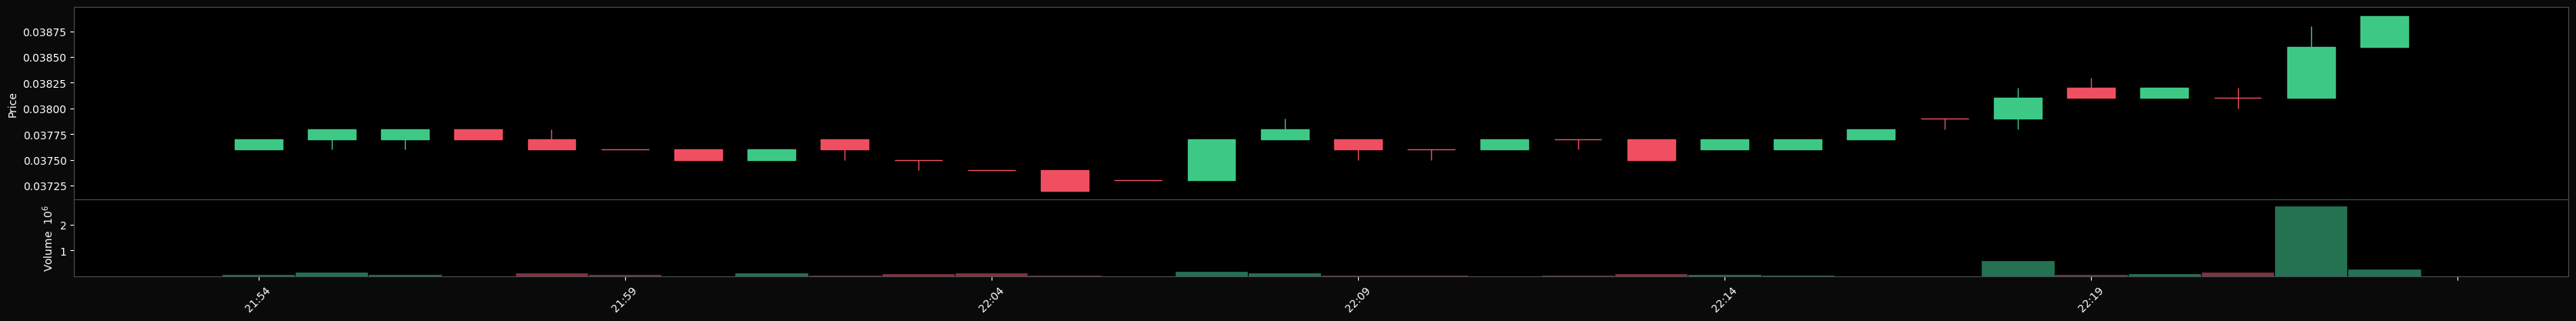

In [9]:
print(top_gainers.idxmax(), top_gainers.max())

kline_columns = [
    "Open Time", "Open", "High", "Low", "Close", "Volume",
    "Close Time", "Quote Asset Volume", "Number of Trades",
    "Taker Buy Base Asset Volume", "Taker Buy Quote Asset Volume", "Ignore"
]

klines_df = pd.DataFrame(klines[top_gainers.idxmax()], columns=pd.Series(kline_columns))

for col in ["Open Time", "Close Time"]:
    klines_df[col] = pd.to_datetime(klines_df[col], unit="ms")

for col in ["Open", "High", "Low", "Close", "Volume"] :
    klines_df[col] = pd.to_numeric(klines_df[col])

klines_df.set_index("Open Time", inplace=True)

style = mpf.make_mpf_style(base_mpf_style="binancedark", gridstyle="", y_on_right=False)
mpf.plot(klines_df, type="candle", volume=True, style=style, figsize=(45, 5))

In [10]:
for _ in range(30):
    time.sleep(60)
    print("last price:", client.get_ticker(symbol=top_gainers.idxmax())["lastPrice"])

last price: 0.03870000
last price: 0.03910000
last price: 0.03880000
last price: 0.03870000
last price: 0.03870000
last price: 0.03850000
last price: 0.03830000
last price: 0.03840000
last price: 0.03840000
last price: 0.03830000
last price: 0.03830000
last price: 0.03830000
last price: 0.03810000
last price: 0.03810000
last price: 0.03790000
last price: 0.03810000
last price: 0.03800000
last price: 0.03800000
last price: 0.03770000
last price: 0.03800000
last price: 0.03780000
last price: 0.03800000
last price: 0.03820000
last price: 0.03840000
last price: 0.03850000
last price: 0.03840000
last price: 0.03890000
last price: 0.03890000
last price: 0.03900000
last price: 0.03920000
